In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#Features of the dataset
df = pd.read_csv('dataset.csv')
len(df)



#Sorts caffeine intake into categorical data 
df['caffeine_groups'] = pd.cut(df['caffeine_intake_cups'],
                               bins = 3,
                               labels = ['0-1 Cups', '2 Cups', '3-4 Cups'])
list(df.columns)

['user_id',
 'age',
 'gender',
 'occupation',
 'daily_screen_time_hours',
 'phone_usage_before_sleep_minutes',
 'sleep_duration_hours',
 'sleep_quality_score',
 'stress_level',
 'caffeine_intake_cups',
 'physical_activity_minutes',
 'notifications_received_per_day',
 'mental_fatigue_score',
 'caffeine_groups']

## Some preliminary hypothesis testing


- H0: Caffeine Intake has no impact on sleep quality
- HA: Caffeine Intake has a negative impact on sleep quality

- alpha = 0.05

In [4]:
from scipy import stats

r, p_value = stats.pearsonr(df['caffeine_intake_cups'], df['sleep_quality_score'])
print(f'Correlation: {r:.4f}')
print(f'P-value: {p_value:.4f}')

Correlation: -0.0090
P-value: 0.2686


p-value of 0.27 is > alpha so we fail to reject H0 and caffeine intake has no significant impact on sleep quality

- H0: Occupation has no impact on stress level 
- HA: Occupation does have an impact on stress level

In [5]:
df['occupation'].values.unique()
df['occupation'].value_counts()

occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

In [6]:
manager = df[df['occupation'] == 'Manager']
doctor = df[df['occupation'] == 'Doctor']
swe = df[df['occupation'] == 'Software Engineer']
freelancer = df[df['occupation'] == 'Freelancer']
student = df[df['occupation'] == 'Student']
researcher = df[df['occupation'] == 'Researcher']
designer = df[df['occupation'] == 'Designer']
teacher = df[df['occupation'] == 'Teacher']

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    manager['sleep_quality_score'],
    doctor['sleep_quality_score'],
    swe['sleep_quality_score'],
    freelancer['sleep_quality_score'],
    student['sleep_quality_score'],
    researcher['sleep_quality_score'],
    designer['sleep_quality_score'],
    teacher['sleep_quality_score'], )

print(p_value)

0.0037833475370639565


By p-value analysis alone, we reject the null hypothesis and say that occupation has an effect on sleep quality.

C:\Users\ryanl\AppData\Local\Temp\ipykernel_11356\2176801048.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels = labels)


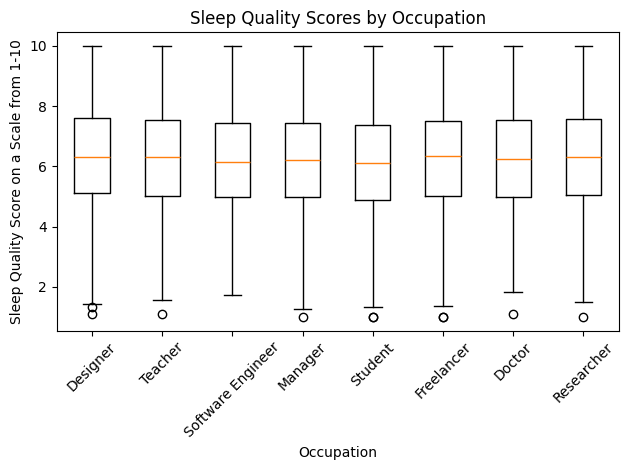

In [11]:
#Graphing
#Taking a look at sleep quality distributions by occupation

groups = [df[df['occupation'] == occ]['sleep_quality_score'] for occ in df['occupation'].unique()]
labels = df['occupation'].unique()

plt.boxplot(groups, labels = labels)
plt.title('Sleep Quality Scores by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Sleep Quality Score on a Scale from 1-10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from pingouin import anova

anova(data = df, dv = 'sleep_quality_score', between = 'occupation', detailed = True)

,Source,SS,DF,MS,F,p_unc,np2
0,occupation,61.617342,7,8.802477,3.000328,0.003783,0.001399
1,Within,43984.104632,14992,2.933838,NaN,NaN,NaN


From the distribution of sleep quality scores by occupation, it is difficult to observe the statistical significance shown by the p-value due to the extremely large samplesize of the dataset. Additionally a more detailed anova test shows a partial eta^2 value (effect size of significance) of 0.0014 which is an extremeley small significant difference.